# Multimodal Failure Mode Analysis: Label Merging & Box Clustering

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

## Setup

In [1]:
import os, json, re, warnings, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

## Constants & Paths

In [2]:
RESULTS_BASE_DIR   = 'results/selection'
VISUAL_BASE_DIR    = 'unimodal/image_corruptions'
TEXTUAL_BASE_DIR   = 'unimodal/text_corruptions'
VARIANT_A_BASE_DIR = 'multimodal/variant_a'
VARIANT_B_BASE_DIR = 'multimodal/variant_b'
OUTPUT_DIR         = 'evaluation/failure_modes'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SCENE_TYPE_MAP = {
    'single/solo':  'Isolated',
    'single/multi': 'Clustered',
    'multi':        'Mixed',
}
SCENE_ORDER = ['Isolated', 'Clustered', 'Mixed']
COND_ORDER = ['Unperturbed', 'Unimodal Visual S4', 'Unimodal Text S4', 'Multimodal A', 'Multimodal B']

SCENE_COLORS = {
    'Isolated':  '#4878A8',
    'Clustered': '#E07B39',
    'Mixed':     '#59A14F',
}
COND_COLORS = ['#999999', '#4878A8', '#E07B39', '#D62728', '#8B0000']

RETAINED_IMG = ['jpeg_filter', 'pixelate', 'defocus_blur', 'motion_blur', 'gaussian_noise', 'fog_filter']
RETAINED_TXT = ['homophone', 'synonym', 'fragmentation', 'character_noise', 'ata_saliency']

TXT_NICE = {
    'homophone': 'Homophone', 'synonym': 'Synonym',
    'fragmentation': 'Fragmentation', 'character_noise': 'Char. Noise',
    'ata_saliency': 'Lex. Saliency',
}

## Helpers

In [3]:
def extract_json_array(text):
    """Extract outermost JSON array from raw VLM output."""
    if not isinstance(text, str):
        return None
    a = text.find('[')
    b = text.rfind(']')
    if a == -1 or b == -1 or b < a:
        return None
    try:
        return json.loads(text[a:b+1])
    except json.JSONDecodeError:
        return None


def get_raw_output(data_dict):
    """Try multiple field names to extract raw VLM text."""
    for field in ['prediction', 'raw_response', 'vlm_output',
                  'model_output', 'output', 'response', 'result']:
        if field in data_dict and isinstance(data_dict[field], str):
            return data_dict[field]
    return ''


def parse_gt_bboxes(gt_dict, img_w, img_h):
    """Parse GT bboxes from {label: {xmin,ymin,xmax,ymax}} format.
    Returns list of (label, area_in_1000x1000_space) and unique labels.
    GT coords are in original image space -> rescale to 1000×1000."""
    entries = []
    labels_all = []
    for key, box in gt_dict.items():
        if not isinstance(box, dict):
            continue
        # Strip instance suffix: person_1 -> person
        parts = key.rsplit('_', 1)
        label = parts[0] if len(parts) == 2 and parts[1].isdigit() else key
        labels_all.append(label.lower())
        # Rescale to 1000×1000 normalised space
        x1 = box.get('xmin', 0) / img_w * 1000
        y1 = box.get('ymin', 0) / img_h * 1000
        x2 = box.get('xmax', 0) / img_w * 1000
        y2 = box.get('ymax', 0) / img_h * 1000
        area = max(0, x2 - x1) * max(0, y2 - y1)
        entries.append({'label': label.lower(), 'area': area,
                        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2})
    return entries, list(set(labels_all))


def parse_predictions(raw_text):
    """Parse VLM output into list of (label, bbox_dict) with area.
    Predictions use bbox_2d: [x1, y1, x2, y2] in 1000×1000 space."""
    parsed = extract_json_array(raw_text)
    if parsed is None or not isinstance(parsed, list):
        return []
    preds = []
    for p in parsed:
        if not isinstance(p, dict):
            continue
        label = p.get('label', p.get('name', p.get('class', '')))
        if not isinstance(label, str):
            label = str(label)
        bbox_2d = p.get('bbox_2d', [])
        if isinstance(bbox_2d, list) and len(bbox_2d) == 4:
            x1, y1, x2, y2 = bbox_2d
            area = max(0, x2 - x1) * max(0, y2 - y1)
        else:
            x1 = y1 = x2 = y2 = 0
            area = 0
        preds.append({'label': label, 'area': area,
                      'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2})
    return preds


def union_area(boxes):
    """Approximate union area of a list of bbox dicts via grid sampling."""
    if not boxes:
        return 0
    # For speed, use bounding-box of union as upper bound,
    # then compute exact union for <=4 boxes via inclusion-exclusion
    # Simple approach: just compute bounding-box area
    x1 = min(b['x1'] for b in boxes)
    y1 = min(b['y1'] for b in boxes)
    x2 = max(b['x2'] for b in boxes)
    y2 = max(b['y2'] for b in boxes)
    return max(0, x2 - x1) * max(0, y2 - y1)


def _norm(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'[\s\u200b\u200d]+', '', text)
    return text.lower()


def label_contains_multiple_classes(pred_label, gt_unique_labels):
    """Check if a single predicted label merges multiple GT class names."""
    pred_norm = _norm(pred_label)
    if len(gt_unique_labels) < 2:
        return False
    matches = 0
    for gt_lbl in gt_unique_labels:
        gt_n = _norm(gt_lbl)
        if gt_n in pred_norm or difflib.SequenceMatcher(None, gt_n, pred_norm).ratio() > 0.5:
            matches += 1
    return matches >= 2

## Load Data Across All Conditions

In [4]:
records = []
load_errors = []

for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    sel_dir = os.path.join(RESULTS_BASE_DIR, rel_dir)
    vis_dir = os.path.join(VISUAL_BASE_DIR, rel_dir)
    txt_dir = os.path.join(TEXTUAL_BASE_DIR, rel_dir)
    va_dir  = os.path.join(VARIANT_A_BASE_DIR, rel_dir)
    vb_dir  = os.path.join(VARIANT_B_BASE_DIR, rel_dir)

    if not os.path.isdir(sel_dir):
        load_errors.append(f'MISSING: {sel_dir}'); continue

    folder_ids = sorted(int(d) for d in os.listdir(sel_dir) if d.isdigit())

    for fid in folder_ids:
        fid_s = str(fid)

        orig_path = os.path.join(sel_dir, fid_s, 'original.json')
        if not os.path.isfile(orig_path):
            load_errors.append(f'MISSING original: {orig_path}'); continue
        with open(orig_path) as f:
            orig = json.load(f)

        gt_raw = orig.get('ground_truth', {})
        img_dims = orig.get('original_dims', orig.get('inference_dims', [1, 1]))
        img_h, img_w = img_dims[0], img_dims[1]  # [height, width]
        gt_entries, gt_unique = parse_gt_bboxes(gt_raw, img_w, img_h)
        n_gt = len(gt_entries)
        mean_gt_area = np.mean([e['area'] for e in gt_entries]) if gt_entries else 0
        gt_union = union_area(gt_entries)

        base_rec = {
            'scene_type': scene_label,
            'sample_id': fid,
            'n_gt': n_gt,
            'n_unique_labels': len(gt_unique),
            'gt_unique_labels': gt_unique,
            'mean_gt_area': mean_gt_area,
            'gt_union_area': gt_union,
        }

        def make_record(condition, raw_text, extra=None):
            preds = parse_predictions(raw_text)
            rec = {**base_rec, 'condition': condition}
            rec['n_preds'] = len(preds)
            rec['pred_labels'] = [p['label'] for p in preds]
            rec['mean_pred_area'] = np.mean([p['area'] for p in preds]) if preds else 0
            rec['max_pred_area'] = max([p['area'] for p in preds]) if preds else 0
            rec['total_pred_area'] = sum(p['area'] for p in preds)
            rec['raw_output'] = raw_text
            if extra:
                rec.update(extra)
            return rec

        records.append(make_record('Unperturbed', get_raw_output(orig)))

        vis_path = os.path.join(vis_dir, fid_s, 'scale_4_IMG.json')
        best_vis_raw, best_vis_iou = '', 1.0
        if os.path.isfile(vis_path):
            with open(vis_path) as f:
                vis_data = json.load(f)
            for atk in RETAINED_IMG:
                entry = vis_data.get('corruptions', {}).get(atk, {})
                iou_val = entry.get('IoU', 1.0)
                if iou_val < best_vis_iou:
                    best_vis_iou = iou_val
                    best_vis_raw = entry.get('result', '')
        records.append(make_record('Unimodal Visual S4', best_vis_raw))

        txt_path = os.path.join(txt_dir, fid_s, 'scale_4_TEXT.json')
        best_txt_raw, best_txt_iou, best_txt_atk = '', 1.0, ''
        if os.path.isfile(txt_path):
            with open(txt_path) as f:
                txt_data = json.load(f)
            for atk in RETAINED_TXT:
                entry = txt_data.get('corruptions', {}).get(atk, {})
                iou_val = entry.get('IoU', 1.0)
                if iou_val < best_txt_iou:
                    best_txt_iou = iou_val
                    best_txt_raw = entry.get('result', '')
                    best_txt_atk = atk
        records.append(make_record('Unimodal Text S4', best_txt_raw))

        for variant_label, var_dir in [('Multimodal A', va_dir), ('Multimodal B', vb_dir)]:
            pf_path = os.path.join(var_dir, fid_s, 'pareto_front.json')
            extra = {}
            if not os.path.isfile(pf_path):
                load_errors.append(f'MISSING {variant_label}: {pf_path}')
                records.append(make_record(variant_label, '', extra))
                continue
            with open(pf_path) as f:
                pf = json.load(f)
            swad_sol = pf['solutions'][pf['swad_star_index']]
            mm_raw = swad_sol['vlm_output'].get('raw_response', '')
            if variant_label == 'Multimodal A':
                extra['txt_attack'] = swad_sol['genome'].get('txt_attack', '')
                extra['img_attack'] = swad_sol['genome'].get('img_attack', '')
            records.append(make_record(variant_label, mm_raw, extra))

df = pd.DataFrame(records)

print(f'Loaded {len(df)} records ({len(df)//5} samples × 5 conditions expected)')
print(f'Load errors: {len(load_errors)}')
if load_errors:
    for e in load_errors[:5]: print(f'  {e}')
print()
print(df.groupby(['condition', 'scene_type']).size().unstack(fill_value=0))

Loaded 3750 records (750 samples × 5 conditions expected)
Load errors: 0

scene_type          Clustered  Isolated  Mixed
condition                                     
Multimodal A              250       250    250
Multimodal B              250       250    250
Unimodal Text S4          250       250    250
Unimodal Visual S4        250       250    250
Unperturbed               250       250    250


In [5]:
print('=== Area Sanity Check (Unperturbed) ===')
unp = df[df.condition == 'Unperturbed']
for st in SCENE_ORDER:
    sub = unp[unp.scene_type == st]
    print(f'{st:<12} mean_gt_area={sub.mean_gt_area.mean():>10.1f}  '
          f'mean_pred_area={sub.mean_pred_area.mean():>10.1f}  '
          f'gt_union={sub.gt_union_area.mean():>10.1f}  '
          f'n_with_preds={(sub.n_preds>0).sum()}/{len(sub)}')

=== Area Sanity Check (Unperturbed) ===
Isolated     mean_gt_area=  300130.6  mean_pred_area=  294269.9  gt_union=  300130.6  n_with_preds=250/250
Clustered    mean_gt_area=  220547.1  mean_pred_area=  214810.3  gt_union=  588059.9  n_with_preds=250/250
Mixed        mean_gt_area=  213201.3  mean_pred_area=  201205.5  gt_union=  651999.4  n_with_preds=250/250


## Prediction Count Deflation

In [6]:
df['pred_ratio'] = df['n_preds'] / df['n_gt'].clip(lower=1)
df['pred_deficit'] = df['n_gt'] - df['n_preds']

print('=== Mean Prediction Count and Ratio by Condition and Scene Type ===')
print(f'{"Condition":<22} {"Scene":<12} {"n_gt":>5} {"n_pred":>7} {"ratio":>7} {"deficit":>8} {"zero%":>7}')
print('-' * 72)
for cond in COND_ORDER:
    for st in SCENE_ORDER:
        sub = df[(df.condition == cond) & (df.scene_type == st)]
        if len(sub) == 0: continue
        zero_pct = 100 * (sub.n_preds == 0).mean()
        print(f'{cond:<22} {st:<12} {sub.n_gt.mean():>5.1f} {sub.n_preds.mean():>7.2f} '
              f'{sub.pred_ratio.mean():>7.3f} {sub.pred_deficit.mean():>+8.2f} {zero_pct:>6.1f}%')
    print()

=== Mean Prediction Count and Ratio by Condition and Scene Type ===
Condition              Scene         n_gt  n_pred   ratio  deficit   zero%
------------------------------------------------------------------------
Unperturbed            Isolated       1.0    1.04   1.044    -0.04    0.0%
Unperturbed            Clustered      3.0    3.10   1.039    -0.08    0.0%
Unperturbed            Mixed          4.1    4.67   1.135    -0.61    0.0%

Unimodal Visual S4     Isolated       1.0    1.03   1.028    -0.03    0.0%
Unimodal Visual S4     Clustered      3.0    1.98   0.743    +1.04    1.2%
Unimodal Visual S4     Mixed          4.1    3.10   0.851    +0.96    4.4%

Unimodal Text S4       Isolated       1.0    1.05   1.052    -0.05    1.6%
Unimodal Text S4       Clustered      3.0    1.86   0.652    +1.16    3.6%
Unimodal Text S4       Mixed          4.1    2.94   0.782    +1.12    6.4%

Multimodal A           Isolated       1.0    0.92   0.924    +0.08   13.6%
Multimodal A           Clustere

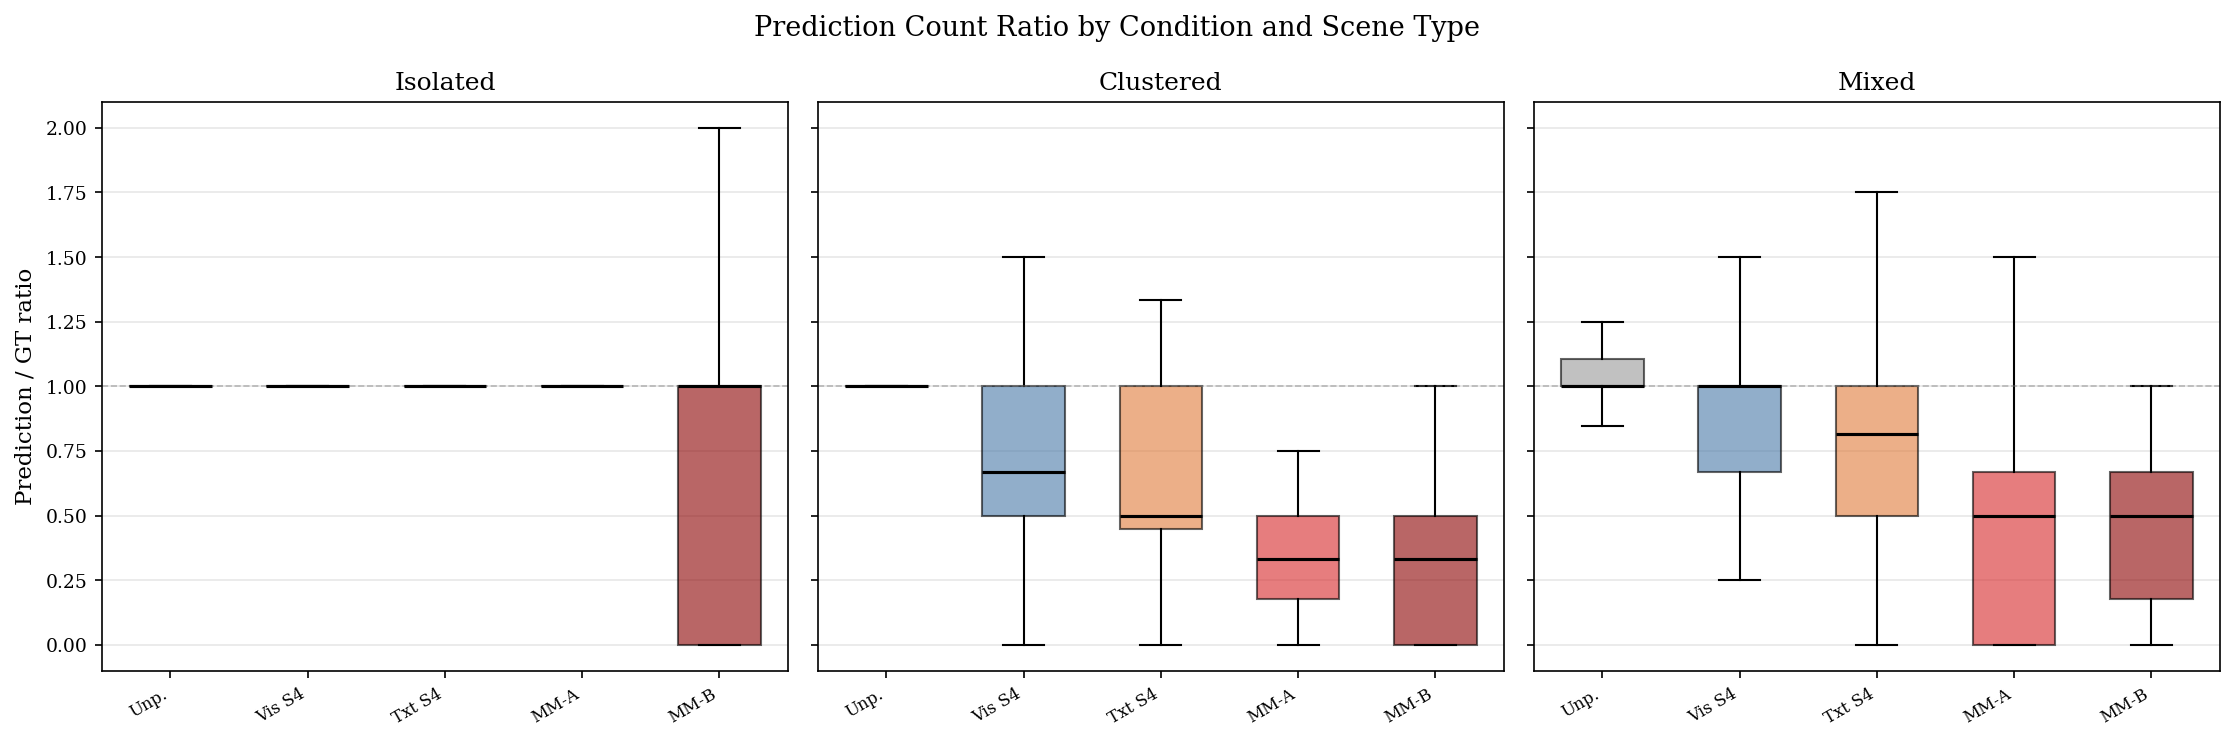

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, st in zip(axes, SCENE_ORDER):
    sub = df[df.scene_type == st]
    plot_data = [sub[sub.condition == c]['pred_ratio'].values for c in COND_ORDER]
    bp = ax.boxplot(plot_data, vert=True, patch_artist=True, showfliers=False,
                    widths=0.6, medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, color in zip(bp['boxes'], COND_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_xticklabels(['Unp.', 'Vis S4', 'Txt S4', 'MM-A', 'MM-B'], rotation=30, ha='right', fontsize=8)
    ax.set_title(st)
    ax.axhline(1.0, ls='--', color='grey', alpha=0.5, lw=0.8)
    ax.set_ylabel('Prediction / GT ratio' if st == 'Isolated' else '')
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle('Prediction Count Ratio by Condition and Scene Type', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_pred_count_ratio.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_pred_count_ratio.png'), dpi=200)
plt.show()

## Label Merging Analysis (Mixed Context)

In [8]:
merge_records = []
for _, row in df[df.scene_type == 'Mixed'].iterrows():
    gt_unique = row['gt_unique_labels']
    pred_labels = row['pred_labels']
    n_merged = sum(1 for pl in pred_labels if label_contains_multiple_classes(pl, gt_unique))
    merged_examples = [pl for pl in pred_labels if label_contains_multiple_classes(pl, gt_unique)]
    n_comma_labels = sum(1 for pl in pred_labels if ',' in pl)
    merge_records.append({
        'condition': row['condition'], 'sample_id': row['sample_id'],
        'n_preds': row['n_preds'], 'n_gt': row['n_gt'],
        'n_merged': n_merged, 'n_comma_labels': n_comma_labels,
        'has_merge': n_merged > 0, 'has_comma': n_comma_labels > 0,
        'merged_examples': merged_examples,
        'txt_attack': row.get('txt_attack', ''),
    })

df_merge = pd.DataFrame(merge_records)

print('=== Label Merging in Mixed Context Scenes ===')
print(f'{"Condition":<22} {"N":>5} {"merge%":>8} {"comma%":>8} {"mean_merged":>12}')
print('-' * 58)
for cond in COND_ORDER:
    sub = df_merge[df_merge.condition == cond]
    if len(sub) == 0: continue
    print(f'{cond:<22} {len(sub):>5} {100*sub.has_merge.mean():>7.1f}% '
          f'{100*sub.has_comma.mean():>7.1f}% {sub.n_merged.mean():>12.3f}')

=== Label Merging in Mixed Context Scenes ===
Condition                  N   merge%   comma%  mean_merged
----------------------------------------------------------
Unperturbed              250     5.6%     0.0%        0.172
Unimodal Visual S4       250     5.6%     0.8%        0.164
Unimodal Text S4         250     4.8%    38.0%        0.084
Multimodal A             250    11.2%    45.2%        0.168
Multimodal B             250    19.2%    70.8%        0.332


In [9]:
print('=== Examples of Merged Labels (Multimodal A, Mixed Context) ===')
examples = df_merge[(df_merge.condition == 'Multimodal A') & (df_merge.n_merged > 0)]
for _, row in examples.head(10).iterrows():
    print(f'\nSample {row["sample_id"]} (GT: {row["n_gt"]} objects, Preds: {row["n_preds"]})')
    for lbl in row['merged_examples']:
        print(f'  Merged label: "{lbl}"')

=== Examples of Merged Labels (Multimodal A, Mixed Context) ===

Sample 6 (GT: 2 objects, Preds: 1)
  Merged label: "ahir dwyer, person"

Sample 48 (GT: 2 objects, Preds: 1)
  Merged label: "lip shtick, pearson"

Sample 55 (GT: 4 objects, Preds: 2)
  Merged label: "guitaa, taep palyer"
  Merged label: "guitaa, taep palyer"

Sample 61 (GT: 3 objects, Preds: 2)
  Merged label: "per son, spat you la"
  Merged label: "per son, spat you la"

Sample 70 (GT: 3 objects, Preds: 1)
  Merged label: "с​orksc​r​ew, ha‍mmer‍"

Sample 81 (GT: 2 objects, Preds: 1)
  Merged label: "br‍as​sierе, per​son"

Sample 86 (GT: 4 objects, Preds: 1)
  Merged label: "purse on, ray"

Sample 87 (GT: 3 objects, Preds: 1)
  Merged label: "cher, mini squirt, per son"

Sample 97 (GT: 2 objects, Preds: 1)
  Merged label: "bathing kap, per son"

Sample 107 (GT: 2 objects, Preds: 1)
  Merged label: "banned aid, per son"


In [10]:
mm_a_merge = df_merge[(df_merge.condition == 'Multimodal A') & (df_merge.txt_attack != '')].copy()
if len(mm_a_merge) > 0:
    print('=== Label Merging by Text Attack Type (Variant A, Mixed) ===')
    print(f'{"Text Attack":<18} {"N":>5} {"merge_rate":>10} {"comma_rate":>11} {"mean_merged":>12}')
    print('-' * 60)
    for atk in RETAINED_TXT:
        sub = mm_a_merge[mm_a_merge.txt_attack == atk]
        if len(sub) == 0: continue
        print(f'{TXT_NICE.get(atk, atk):<18} {len(sub):>5} '
              f'{100*sub.has_merge.mean():>9.1f}% {100*sub.has_comma.mean():>10.1f}% '
              f'{sub.n_merged.mean():>12.3f}')

=== Label Merging by Text Attack Type (Variant A, Mixed) ===
Text Attack            N merge_rate  comma_rate  mean_merged
------------------------------------------------------------
Homophone            157      13.4%       47.1%        0.191
Synonym               11       0.0%       18.2%        0.000
Char. Noise           27      11.1%       44.4%        0.111
Lex. Saliency         55       7.3%       45.5%        0.164


## Box Clustering Analysis (Clustered Scenes)

In [11]:
df_wp = df[(df.n_preds > 0)].copy()
df_wp['area_ratio'] = df_wp['mean_pred_area'] / df_wp['mean_gt_area'].clip(lower=1)
df_wp['max_pred_vs_gt_union'] = df_wp['max_pred_area'] / df_wp['gt_union_area'].clip(lower=1)

print('=== Box Area Analysis -- Clustered Scenes (samples with ≥1 prediction) ===')
print('  area_ratio = mean_pred_area / mean_gt_area (>1 = predicted boxes larger than GT)')
print('  coverage   = max_pred_area / gt_union_area (->1 = one pred covers all GT)\n')
print(f'{"Condition":<22} {"N":>5} {"area_ratio":>11} {"med":>6} {"ratio>1.5%":>10} '
      f'{"coverage":>9} {"cov>0.8%":>9}')
print('-' * 78)
for cond in COND_ORDER:
    sub = df_wp[(df_wp.condition == cond) & (df_wp.scene_type == 'Clustered')]
    if len(sub) == 0:
        print(f'{cond:<22} {0:>5}'); continue
    r15 = 100 * (sub.area_ratio > 1.5).mean()
    c08 = 100 * (sub.max_pred_vs_gt_union > 0.8).mean()
    print(f'{cond:<22} {len(sub):>5} {sub.area_ratio.mean():>11.3f} '
          f'{sub.area_ratio.median():>6.3f} {r15:>9.1f}% '
          f'{sub.max_pred_vs_gt_union.mean():>9.3f} {c08:>8.1f}%')

=== Box Area Analysis -- Clustered Scenes (samples with ≥1 prediction) ===
  area_ratio = mean_pred_area / mean_gt_area (>1 = predicted boxes larger than GT)
  coverage   = max_pred_area / gt_union_area (->1 = one pred covers all GT)

Condition                  N  area_ratio    med ratio>1.5%  coverage  cov>0.8%
------------------------------------------------------------------------------
Unperturbed              250       0.965  0.971       2.0%     0.487     10.8%
Unimodal Visual S4       247       1.712  1.077      26.7%     0.541     17.8%
Unimodal Text S4         241       1.362  0.981      20.3%     0.480     12.4%
Multimodal A             198       2.353  0.903      30.3%     0.512     20.7%
Multimodal B             173       2.925  0.930      24.9%     0.475     16.8%


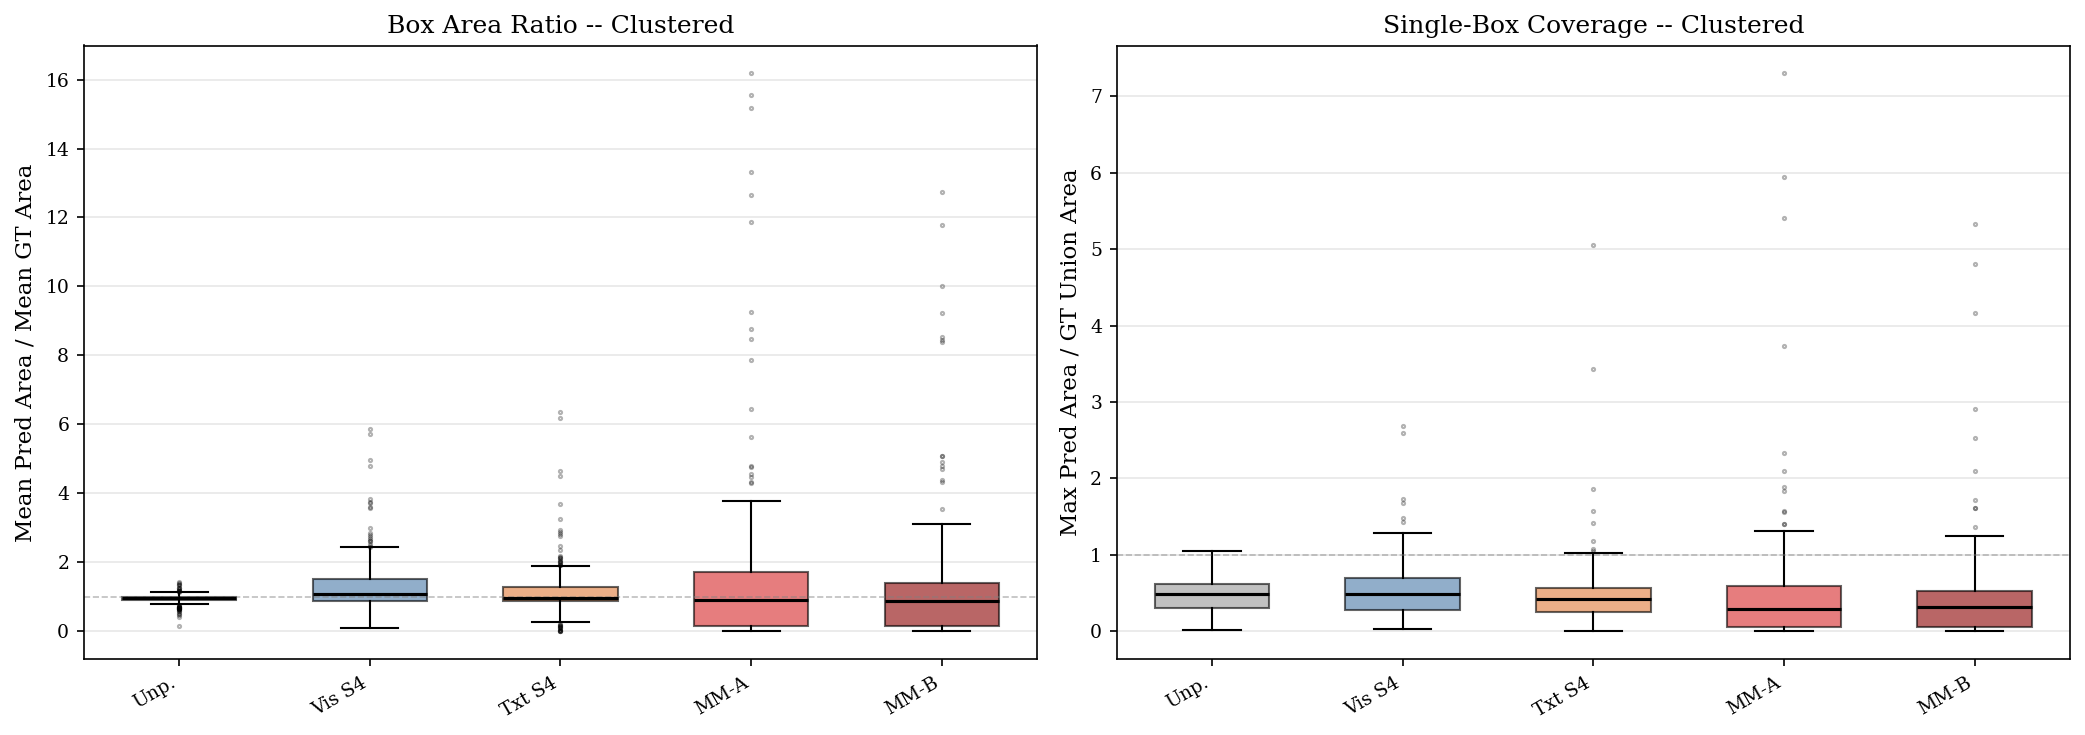

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
clust = df_wp[df_wp.scene_type == 'Clustered']
plot_data = []
for c in COND_ORDER:
    d = clust[clust.condition == c]['area_ratio'].dropna().values
    d = d[d < np.percentile(d, 98)] if len(d) > 10 else d
    plot_data.append(d)
bp = ax.boxplot(plot_data, vert=True, patch_artist=True, showfliers=True,
                widths=0.6, medianprops={'color': 'black', 'linewidth': 1.5},
                flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.3})
for patch, color in zip(bp['boxes'], COND_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xticklabels(['Unp.', 'Vis S4', 'Txt S4', 'MM-A', 'MM-B'], rotation=30, ha='right')
ax.axhline(1.0, ls='--', color='grey', alpha=0.5, lw=0.8)
ax.set_ylabel('Mean Pred Area / Mean GT Area')
ax.set_title('Box Area Ratio -- Clustered')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
plot_data2 = [clust[clust.condition == c]['max_pred_vs_gt_union'].dropna().values for c in COND_ORDER]
bp2 = ax.boxplot(plot_data2, vert=True, patch_artist=True, showfliers=True,
                 widths=0.6, medianprops={'color': 'black', 'linewidth': 1.5},
                 flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.3})
for patch, color in zip(bp2['boxes'], COND_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xticklabels(['Unp.', 'Vis S4', 'Txt S4', 'MM-A', 'MM-B'], rotation=30, ha='right')
ax.axhline(1.0, ls='--', color='grey', alpha=0.5, lw=0.8)
ax.set_ylabel('Max Pred Area / GT Union Area')
ax.set_title('Single-Box Coverage -- Clustered')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_box_area_analysis_clustered.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_box_area_analysis_clustered.png'), dpi=200)
plt.show()

## Surviving Single-Prediction Analysis (Clustered)

In [13]:
print('=== Single-Prediction Survivors on Clustered Scenes ===')
print('(Samples with n_gt ≥ 2 and exactly 1 predicted box)\n')
print(f'{"Condition":<22} {"N (1-pred)":>10} {"of total":>8} {"mean_area_ratio":>15} '
      f'{"mean_coverage":>13} {"coverage>0.5":>12}')
print('-' * 85)
for cond in COND_ORDER:
    sub = df[(df.condition == cond) & (df.scene_type == 'Clustered') &
             (df.n_preds == 1) & (df.n_gt >= 2)]
    total = len(df[(df.condition == cond) & (df.scene_type == 'Clustered')])
    if len(sub) == 0:
        print(f'{cond:<22} {0:>10} {"--":>8}'); continue
    ar = sub['mean_pred_area'] / sub['mean_gt_area'].clip(lower=1)
    cov = sub['max_pred_area'] / sub['gt_union_area'].clip(lower=1)
    print(f'{cond:<22} {len(sub):>10} {len(sub)/total*100:>7.1f}% {ar.mean():>15.3f} '
          f'{cov.mean():>13.3f} {100*(cov>0.5).mean():>11.1f}%')

=== Single-Prediction Survivors on Clustered Scenes ===
(Samples with n_gt ≥ 2 and exactly 1 predicted box)

Condition              N (1-pred) of total mean_area_ratio mean_coverage coverage>0.5
-------------------------------------------------------------------------------------
Unperturbed                     8     3.2%           1.315         0.759        75.0%
Unimodal Visual S4             93    37.2%           2.859         0.685        60.2%
Unimodal Text S4              130    52.0%           1.688         0.528        39.2%
Multimodal A                  165    66.0%           2.684         0.562        33.3%
Multimodal B                  128    51.2%           3.684         0.517        31.2%


In [14]:
df.drop(columns=['raw_output', 'gt_unique_labels', 'pred_labels']).to_csv(
    os.path.join(OUTPUT_DIR, 'failure_mode_analysis.csv'), index=False)
print(f'Saved to {OUTPUT_DIR}/failure_mode_analysis.csv')

Saved to evaluation/failure_modes/failure_mode_analysis.csv
